# Named Entity Recognition in Clinical Text Using Domain-Specific BERT (BioBERT)

**Student Name** : Bhanu Prakash Sige

**Student ID**   : A00080352

**Module**       : Deep Learning Applications (CMP-L016-0)

**University**   : University of Roehampton, London


## Section 1 — Install Required Libraries

Pinned versions ensure reproducibility. The runtime is restarted after install
so the new packages are picked up cleanly by the Python interpreter.

In [ ]:
import os

# Fix torchvision CUDA mismatch first — must happen before any other install
# Uses os.system (same shell process) so the fix persists into the restart
os.system("pip install -q torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121 --force-reinstall")

# Install all project dependencies at pinned versions
os.system("""pip install \
  "transformers==4.46.3" \
  "huggingface_hub==0.26.5" \
  "tokenizers==0.20.3" \
  "accelerate==1.1.1" \
  "datasets==2.14.7" \
  evaluate seqeval optuna \
  --no-cache-dir -q""")

# Restart runtime — "session crashed" message is expected, not an error
os.kill(os.getpid(), 9)

In [ ]:
import sys

# Purge any stale torchvision from Python's module cache
for mod in [m for m in sys.modules
             if "torchvision" in m or "torchaudio" in m]:
    sys.modules.pop(mod)

# This import was the crash point — if it passes, everything will work
from transformers.models.bert import modeling_bert
print("✅ torchvision fix confirmed — continue running remaining cells")

✅ torchvision fix confirmed — continue running remaining cells


## Section 2 — Import Libraries

In [ ]:
# Core scientific and deep learning imports
import os
import torch
import torch.nn.functional as torch_func
import numpy as np
import pandas as pd
import evaluate
import optuna
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
)
from seqeval.metrics import classification_report as span_level_report
from google.colab import drive

# Suppress verbose Optuna internal logs — trial-level custom prints still show
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("All imports successful ✅")

All imports successful ✅


In [ ]:
# Authenticate with Google and mount Drive.
# All model checkpoints and plots will be saved here.
from google.colab import auth
auth.authenticate_user()
drive.mount("/content/drive")

DRIVE_ROOT = "/content/drive/MyDrive/ncbi-ner-project"
os.makedirs(DRIVE_ROOT, exist_ok=True)
print(f"Drive mounted. Project folder: {DRIVE_ROOT}")

Mounted at /content/drive
Drive mounted. Project folder: /content/drive/MyDrive/ncbi-ner-project


In [ ]:
# Verify all packages installed at the correct pinned versions.
import huggingface_hub, transformers, datasets as hf_datasets, accelerate

print(f"huggingface_hub : {huggingface_hub.__version__}")   # 0.26.5
print(f"transformers    : {transformers.__version__}")        # 4.46.3
print(f"datasets        : {hf_datasets.__version__}")         # 2.14.7
print(f"accelerate      : {accelerate.__version__}")          # 1.1.1

assert transformers.__version__ == "4.46.3",     f"Wrong transformers version: {transformers.__version__}"
print("✅ All package versions confirmed")

huggingface_hub : 0.26.5
transformers    : 4.46.3
datasets        : 2.14.7
accelerate      : 1.1.1
✅ All package versions confirmed


## Section 3 — GPU Verification

BioBERT-large has 363M parameters and requires at least 20 GB VRAM.
This notebook is configured for H100 High-Ram

In [ ]:
# Verify GPU availability and VRAM capacity.
# BioBERT-large requires >=20 GB VRAM — H100 is ideal.
compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute device  : {compute_device}")
print(f"PyTorch version : {torch.__version__}")

if torch.cuda.is_available():
    gpu_label    = torch.cuda.get_device_name(0)
    vram_total   = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU model       : {gpu_label}")
    print(f"VRAM total      : {vram_total:.1f} GB")
    if vram_total < 20:
        print("⚠️  WARNING: <20 GB VRAM — BioBERT-large may OOM. Switch to biobert-base.")
    else:
        print("✅ Sufficient VRAM for BioBERT-large")
else:
    raise RuntimeError(
        "No GPU detected. Go to Runtime → Change runtime type → GPU (H100)."
    )

Compute device  : cuda
PyTorch version : 2.5.1+cu121
GPU model       : NVIDIA H100 80GB HBM3
VRAM total      : 85.0 GB
✅ Sufficient VRAM for BioBERT-large


## Section 4 — Load NCBI Disease Dataset

The **NCBI Disease Corpus** is the standard benchmark for biomedical disease NER.
It contains 793 PubMed abstracts annotated with disease entity spans using the BIO scheme:
- `B-Disease` — Beginning of a disease entity
- `I-Disease` — Inside (continuation of) a disease entity
- `O`         — Outside any entity

In [ ]:
# Load the NCBI Disease corpus from Hugging Face Datasets Hub.
# Splits: train (5,433 sentences), validation (924), test (941).
corpus = load_dataset("ncbi_disease")
print(corpus)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/5433 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/924 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/941 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 5433
    })
    validation: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 924
    })
    test: Dataset({
        features: ['id', 'tokens', 'ner_tags'],
        num_rows: 941
    })
})


### 4.1 Explore Dataset Structure

In [ ]:
# Inspect a single training record to understand the data format.
# Each record has: id, tokens (list of words), ner_tags (list of integer label IDs).
first_record = corpus["train"][0]
print("\n--- First Training Record ---")
print(f"ID       : {first_record['id']}")
print(f"Tokens   : {first_record['tokens']}")
print(f"NER tags : {first_record['ner_tags']}")
print(f"Length   : {len(first_record['tokens'])} tokens")

# Analyse sentence length distribution to justify MAX_LENGTH=256
seq_lengths = [len(rec["tokens"]) for rec in corpus["train"]]
print(f"\nToken length statistics (train split):")
print(f"  Max    : {max(seq_lengths)}")
print(f"  Mean   : {sum(seq_lengths)/len(seq_lengths):.1f}")
print(f"  > 128  : {sum(1 for l in seq_lengths if l > 128)} sentences")
print(f"  > 256  : {sum(1 for l in seq_lengths if l > 256)} sentences")
print("\nConclusion: MAX_LENGTH=256 covers 100% of training sentences.")


--- First Training Record ---
ID       : 0
Tokens   : ['Identification', 'of', 'APC2', ',', 'a', 'homologue', 'of', 'the', 'adenomatous', 'polyposis', 'coli', 'tumour', 'suppressor', '.']
NER tags : [0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 0, 0]
Length   : 14 tokens

Token length statistics (train split):
  Max    : 123
  Mean   : 25.0
  > 128  : 0 sentences
  > 256  : 0 sentences

Conclusion: MAX_LENGTH=256 covers 100% of training sentences.


### 4.2 Label Mapping

In [ ]:
# Build integer <-> string label dictionaries.
# label_names  : ['O', 'B-Disease', 'I-Disease']
# tag_to_idx   : {'O': 0, 'B-Disease': 1, 'I-Disease': 2}
# idx_to_tag   : {0: 'O', 1: 'B-Disease', 2: 'I-Disease'}
label_names  = corpus["train"].features["ner_tags"].feature.names
idx_to_tag   = {i: lbl for i, lbl in enumerate(label_names)}
tag_to_idx   = {lbl: i for i, lbl in enumerate(label_names)}
num_bio_tags = len(label_names)

print(f"BIO tag vocabulary ({num_bio_tags} tags): {label_names}")
print(f"idx_to_tag : {idx_to_tag}")

BIO tag vocabulary (3 tags): ['O', 'B-Disease', 'I-Disease']
idx_to_tag : {0: 'O', 1: 'B-Disease', 2: 'I-Disease'}


### 4.3 Class Imbalance Analysis

A critical property of NER datasets is severe class imbalance — the vast majority
of tokens are labelled 'O'. This cell quantifies the imbalance and visualises it,
motivating the use of **entity-level seqeval** metrics rather than token accuracy.

Label distribution across all splits:

  --- TRAIN (5433 sentences, 136086 tokens) ---
    O            (id=0):  124819  (91.7%)
    B-Disease    (id=1):    5145  (3.8%)
    I-Disease    (id=2):    6122  (4.5%)

  --- VALIDATION (924 sentences, 23969 tokens) ---
    O            (id=0):   22092  (92.2%)
    B-Disease    (id=1):     787  (3.3%)
    I-Disease    (id=2):    1090  (4.5%)

  --- TEST (941 sentences, 24497 tokens) ---
    O            (id=0):   22450  (91.6%)
    B-Disease    (id=1):     960  (3.9%)
    I-Disease    (id=2):    1087  (4.4%)



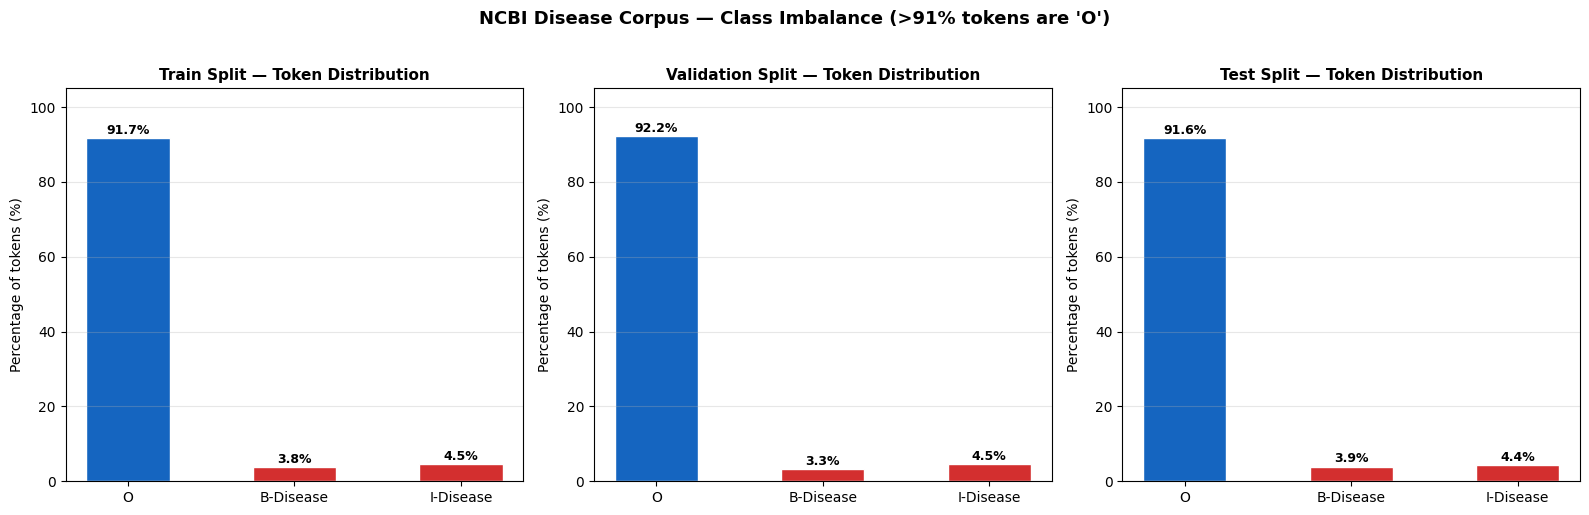


✅ Class imbalance chart saved → /content/drive/MyDrive/ncbi-ner-project/class_imbalance.png

Key insight: 91%+ O-tokens means token accuracy is misleading.
We use seqeval entity-level F1 as the primary evaluation metric.


In [ ]:
# Count label frequencies per split and visualise class imbalance.
# This motivates using seqeval (entity-level) metrics instead of token accuracy,
# because >91% O-tokens would give misleadingly high token-level accuracy.

split_tag_counts = {}
print("Label distribution across all splits:\n")
for split_name in ["train", "validation", "test"]:
    flat_tags   = [tag for rec in corpus[split_name] for tag in rec["ner_tags"]]
    tag_counter = Counter(flat_tags)
    total_toks  = len(flat_tags)
    split_tag_counts[split_name] = (tag_counter, total_toks)
    print(f"  --- {split_name.upper()} ({len(corpus[split_name])} sentences, {total_toks} tokens) ---")
    for tag_id, cnt in sorted(tag_counter.items()):
        pct = cnt / total_toks * 100
        print(f"    {idx_to_tag[tag_id]:12s} (id={tag_id}): {cnt:7d}  ({pct:.1f}%)")
    print()

# ── Class imbalance bar chart — saved to Drive ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, split_name in zip(axes, ["train", "validation", "test"]):
    tag_counter, total_toks = split_tag_counts[split_name]
    tag_labels = [idx_to_tag[i] for i in sorted(tag_counter)]
    tag_pcts   = [tag_counter[i] / total_toks * 100 for i in sorted(tag_counter)]
    bar_colors = ["#d32f2f" if "Disease" in l else "#1565c0" for l in tag_labels]
    bars = ax.bar(tag_labels, tag_pcts, color=bar_colors, edgecolor="white", width=0.5)
    for bar, pct in zip(bars, tag_pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(f"{split_name.capitalize()} Split — Token Distribution",
                 fontweight="bold", fontsize=11)
    ax.set_ylabel("Percentage of tokens (%)")
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("NCBI Disease Corpus — Class Imbalance (>91% tokens are 'O')",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

imbalance_plot_path = f"{DRIVE_ROOT}/class_imbalance.png"
plt.savefig(imbalance_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ Class imbalance chart saved → {imbalance_plot_path}")
print("\nKey insight: 91%+ O-tokens means token accuracy is misleading.")
print("We use seqeval entity-level F1 as the primary evaluation metric.")

### 4.4 Visualise a Sample Sentence with BIO Labels

In [ ]:
# Display a training sentence that contains disease entities,
# showing each token alongside its BIO label for visual inspection.
def render_bio_sample(record, idx_to_tag):
    """Print tokens and their BIO labels side by side for inspection."""
    print(f"{'Token':<25} {'BIO Label'}")
    print("-" * 42)
    for token, tag_id in zip(record["tokens"], record["ner_tags"]):
        tag_str = idx_to_tag[tag_id]
        marker  = "  <<< DISEASE" if tag_str != "O" else ""
        print(f"{token:<25} {tag_str}{marker}")

# Find the first training record that contains at least one disease entity
for rec in corpus["train"]:
    if any(t != 0 for t in rec["ner_tags"]):
        render_bio_sample(rec, idx_to_tag)
        break

Token                     BIO Label
------------------------------------------
Identification            O
of                        O
APC2                      O
,                         O
a                         O
homologue                 O
of                        O
the                       O
adenomatous               B-Disease  <<< DISEASE
polyposis                 I-Disease  <<< DISEASE
coli                      I-Disease  <<< DISEASE
tumour                    I-Disease  <<< DISEASE
suppressor                O
.                         O


## Load the BioBERT-large tokenizer

In [ ]:
# Load the BioBERT-large tokenizer.
# MODEL_BASE_ID is the Hugging Face model identifier for pre-trained weights.
MODEL_BASE_ID = "dmis-lab/biobert-large-cased-v1.1"
SEQ_MAX_LEN   = 256   # covers 100% of NCBI samples; reduces memory vs 512

bio_tokenizer = AutoTokenizer.from_pretrained(MODEL_BASE_ID)
bio_tokenizer.model_max_length = 512   # suppress internal warning

print(f"Tokenizer loaded : {MODEL_BASE_ID}")
print(f"Vocabulary size  : {bio_tokenizer.vocab_size}")
print(f"SEQ_MAX_LEN used : {SEQ_MAX_LEN}")

# Demonstrate WordPiece subword splitting on a sample disease name
demo_sent  = "The patient was diagnosed with Huntington disease and cognitive impairment."
demo_toks  = bio_tokenizer.tokenize(demo_sent)
print(f"\nExample tokenization:")
print(f"  Input  : {demo_sent}")
print(f"  Tokens : {demo_toks}")

config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded : dmis-lab/biobert-large-cased-v1.1
Vocabulary size  : 58996
SEQ_MAX_LEN used : 256

Example tokenization:
  Input  : The patient was diagnosed with Huntington disease and cognitive impairment.
  Tokens : ['the', 'patient', 'was', 'diagnosed', 'with', 'hunting', '##ton', 'disease', 'and', 'cognitive', 'imp', '##air', '##ment', '.']


## Section 5 — Tokenisation with WordPiece Label Alignment

BioBERT uses WordPiece tokenisation, which splits words into subword units.
This creates a mismatch between word-level NER labels and subword tokens.
The alignment strategy assigns the original label to the **first subword** only;
all continuation pieces receive label `-100` (ignored by the loss function).

In [ ]:
# Tokenise a batch of sentences and align NER labels to subword tokens.
# Strategy:
#   - First subword of each word  → original NER tag
#   - Continuation subwords       → -100  (ignored in loss)
#   - Special tokens [CLS], [SEP] → -100  (ignored in loss)

def encode_and_align_bio_tags(batch, propagate_inside=False):
    """
    Tokenise a batch and produce aligned label IDs for BioBERT NER training.

    Parameters
    ----------
    batch            : HuggingFace dataset batch dict with 'tokens' and 'ner_tags'
    propagate_inside : If True, continuation subwords inherit the first-piece label.
                       Default False (standard approach: -100 for continuations).

    Returns
    -------
    encoded : tokenizer output dict with an added 'labels' key
    """
    encoded = bio_tokenizer(
        batch["tokens"],
        truncation=True,
        is_split_into_words=True,
        padding="max_length",
        max_length=SEQ_MAX_LEN,
    )

    aligned_label_batch = []
    for seq_idx, raw_tags in enumerate(batch["ner_tags"]):
        word_positions  = encoded.word_ids(batch_index=seq_idx)
        prev_word_pos   = None
        aligned_seq     = []

        for word_pos in word_positions:
            if word_pos is None:                       # special token
                aligned_seq.append(-100)
            elif word_pos != prev_word_pos:            # first piece of a word
                aligned_seq.append(raw_tags[word_pos])
            else:                                      # continuation piece
                aligned_seq.append(
                    raw_tags[word_pos] if propagate_inside else -100
                )
            prev_word_pos = word_pos

        aligned_label_batch.append(aligned_seq)

    encoded["labels"] = aligned_label_batch
    return encoded

### 5.1 Visualise Label Alignment on a Real Sample

In [ ]:
# Show how WordPiece tokenisation and label alignment work on a real sentence.
# This demonstrates that continuation subwords get -100 (ignored in training).
entity_sample_idx = next(
    i for i, s in enumerate(corpus["train"])
    if any(t != 0 for t in s["ner_tags"])
)
entity_sample = corpus["train"][entity_sample_idx]
print(f"Visualising sample {entity_sample_idx} (contains disease entities)\n")

enc_sample  = bio_tokenizer(entity_sample["tokens"], is_split_into_words=True)
subword_seq = bio_tokenizer.convert_ids_to_tokens(enc_sample["input_ids"])
word_pos_seq = enc_sample.word_ids()

prev_pos, aligned_seq = None, []
for wp in word_pos_seq:
    if wp is None:          aligned_seq.append(-100)
    elif wp != prev_pos:    aligned_seq.append(entity_sample["ner_tags"][wp])
    else:                   aligned_seq.append(-100)
    prev_pos = wp

print(f"{'Subword':<22} {'WordID':<8} {'Original':<14} {'Aligned':<20} {'Note'}")
print("─" * 85)
for subword, wpos, aligned in zip(subword_seq[:28], word_pos_seq[:28], aligned_seq[:28]):
    orig_str    = idx_to_tag[entity_sample["ner_tags"][wpos]] if wpos is not None else "SPECIAL"
    aligned_str = "-100 (skip)" if aligned == -100 else idx_to_tag[aligned]
    if wpos is None:                             note = "← special token"
    elif aligned not in (-100, 0):               note = "← DISEASE first piece ✅"
    elif aligned == -100 and wpos is not None:   note = "← subword continuation, skipped"
    else:                                        note = ""
    print(f"{subword:<22} {str(wpos):<8} {orig_str:<14} {aligned_str:<20} {note}")

Visualising sample 0 (contains disease entities)

Subword                WordID   Original       Aligned              Note
─────────────────────────────────────────────────────────────────────────────────────
[CLS]                  None     SPECIAL        -100 (skip)          ← special token
identification         0        O              O                    
of                     1        O              O                    
ap                     2        O              O                    
##c                    2        O              -100 (skip)          ← subword continuation, skipped
##2                    2        O              -100 (skip)          ← subword continuation, skipped
,                      3        O              O                    
a                      4        O              O                    
hom                    5        O              O                    
##olo                  5        O              -100 (skip)          ← subword continuation, s

### 5.2 Apply Tokenisation to Full Dataset

In [ ]:
# Apply encode_and_align_bio_tags to all three splits in batch mode.
# remove_columns drops the original string columns — only tensors remain.
encoded_corpus = corpus.map(
    encode_and_align_bio_tags,
    batched=True,
    remove_columns=corpus["train"].column_names,
)

print("Tokenisation complete!")
print(f"Encoded corpus  : {encoded_corpus}")
print(f"\nFeature keys    : {list(encoded_corpus['train'][0].keys())}")
print(f"input_ids length: {len(encoded_corpus['train'][0]['input_ids'])}")
print(f"labels length   : {len(encoded_corpus['train'][0]['labels'])}")

Map:   0%|          | 0/5433 [00:00<?, ? examples/s]

Map:   0%|          | 0/924 [00:00<?, ? examples/s]

Map:   0%|          | 0/941 [00:00<?, ? examples/s]

Tokenisation complete!
Encoded corpus  : DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 5433
    })
    validation: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 924
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 941
    })
})

Feature keys    : ['input_ids', 'token_type_ids', 'attention_mask', 'labels']
input_ids length: 256
labels length   : 256


## Section 6 — Load BioBERT for Token Classification

`AutoModelForTokenClassification` appends a linear classification head
(hidden_size → num_labels) on top of the BioBERT encoder stack.

In [ ]:
# Load BioBERT-large with a token classification head.
# idx_to_tag and tag_to_idx are stored in the model config for later inference.
biobert_ner = AutoModelForTokenClassification.from_pretrained(
    MODEL_BASE_ID,
    num_labels = num_bio_tags,
    id2label   = idx_to_tag,
    label2id   = tag_to_idx,
)
biobert_ner = biobert_ner.to(compute_device)

total_param_count     = sum(p.numel() for p in biobert_ner.parameters())
trainable_param_count = sum(p.numel() for p in biobert_ner.parameters() if p.requires_grad)

print(f"Architecture        : {biobert_ner.config.model_type}")
print(f"Total parameters    : {total_param_count:,}")
print(f"Trainable parameters: {trainable_param_count:,}")
print(f"Output classes      : {num_bio_tags}  {label_names}")

pytorch_model.bin:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-large-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Architecture        : bert
Total parameters    : 363,252,739
Trainable parameters: 363,252,739
Output classes      : 3  ['O', 'B-Disease', 'I-Disease']


## Section 7 — Entity-Level Evaluation Metric

`seqeval` computes **span-level** Precision, Recall, and F1.
A prediction is correct only if the full entity span — start, end, and type —
matches the gold annotation exactly. This avoids inflated scores from the
dominant 'O' class.

In [ ]:
# Load seqeval and define compute_span_metrics.
# Called by the Trainer after every epoch to report val F1.
# Token-level accuracy is intentionally excluded — inflated by 91% O tokens.
seqeval_metric = evaluate.load("seqeval")

def compute_span_metrics(prediction_output):
    """
    Compute entity-level Precision, Recall, F1 from Trainer eval_preds.

    Filters out -100 padding positions before calling seqeval,
    ensuring only real word-level predictions are scored.
    """
    raw_logits, raw_gold = prediction_output
    predicted_ids        = np.argmax(raw_logits, axis=-1)

    # Remove padding (-100) positions and convert IDs to string labels
    gold_tag_seqs = [
        [label_names[lbl] for lbl in gold_row if lbl != -100]
        for gold_row in raw_gold
    ]
    pred_tag_seqs = [
        [label_names[pred] for pred, gold in zip(pred_row, gold_row) if gold != -100]
        for pred_row, gold_row in zip(predicted_ids, raw_gold)
    ]

    span_results = seqeval_metric.compute(
        predictions=pred_tag_seqs, references=gold_tag_seqs
    )

    # Collect per-entity-type F1 scores (e.g. "Disease")
    per_type_f1 = {}
    for key, val in span_results.items():
        if isinstance(val, dict):
            per_type_f1[key] = round(val.get("f1", 0), 4)

    metric_output = {
        "precision": round(span_results["overall_precision"], 4),
        "recall"   : round(span_results["overall_recall"],    4),
        "f1"       : round(span_results["overall_f1"],        4),
    }
    metric_output.update({f"f1_{k}": v for k, v in per_type_f1.items()})
    return metric_output

print("compute_span_metrics defined ✅")

compute_span_metrics defined ✅


## Section 8 — Optuna Hyperparameter Search

Optuna uses the **Tree-structured Parzen Estimator (TPE)** algorithm —
a Bayesian method that focuses future trials on regions of the search space
that yielded high validation F1 in previous trials.

Each trial trains a fresh BioBERT instance for up to `max_epochs` epochs
with early stopping (patience=2). The trial returns the best validation F1
observed across all epochs.

In [ ]:
# Configuration for early stopping shared by Optuna trials and final training.
HP_EARLY_STOP_PATIENCE  = 2
HP_EARLY_STOP_THRESHOLD = 0.001

# Storage for all trial results — used for analysis and plotting later
trial_run_log = []

def run_hpo_trial(trial):

    # Sample hyperparameters from defined search space
    learning_rate  = trial.suggest_categorical("lr",           [1e-5, 2e-5, 3e-5, 4e-5])
    batch_sz       = trial.suggest_categorical("batch_size",   [16, 32])
    max_ep         = trial.suggest_int("epochs",               5, 10)
    decay_strength = trial.suggest_categorical("weight_decay", [0.0, 0.01, 0.1])
    warmup_frac    = trial.suggest_categorical("warmup_ratio", [0.06, 0.1, 0.2])

    print(f"\n{'='*60}")
    print(f"Trial {trial.number:02d}  lr={learning_rate}  bs={batch_sz}  "
          f"ep={max_ep}  wd={decay_strength}  wr={warmup_frac}")
    print(f"{'='*60}")

    # Fresh model instance per trial — prevents weight leakage between trials
    trial_biobert = AutoModelForTokenClassification.from_pretrained(
        MODEL_BASE_ID,
        num_labels = num_bio_tags,
        id2label   = idx_to_tag,
        label2id   = tag_to_idx,
    ).to(compute_device)

    trial_ckpt_dir = f"/tmp/hpo-trial-{trial.number}"

    trial_train_args = TrainingArguments(
        output_dir                  = trial_ckpt_dir,
        evaluation_strategy         = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        metric_for_best_model       = "f1",
        greater_is_better           = True,
        save_total_limit            = 1,
        learning_rate               = learning_rate,
        per_device_train_batch_size = batch_sz,
        per_device_eval_batch_size  = batch_sz,
        num_train_epochs            = max_ep,
        weight_decay                = decay_strength,
        warmup_ratio                = warmup_frac,
        bf16                        = torch.cuda.is_available(),
        logging_steps               = 100,
        logging_dir                 = None,
        report_to                   = "none",
        dataloader_num_workers      = 4,
    )

    trial_trainer = Trainer(
        model           = trial_biobert,
        args            = trial_train_args,
        train_dataset   = encoded_corpus["train"],
        eval_dataset    = encoded_corpus["validation"],
        tokenizer       = bio_tokenizer,
        data_collator   = DataCollatorForTokenClassification(bio_tokenizer),
        compute_metrics = compute_span_metrics,
        callbacks       = [EarlyStoppingCallback(
            early_stopping_patience  = HP_EARLY_STOP_PATIENCE,
            early_stopping_threshold = HP_EARLY_STOP_THRESHOLD,
        )],
    )

    train_outcome  = trial_trainer.train()
    val_outcome    = trial_trainer.evaluate()

    actual_ep_ran  = int(train_outcome.metrics.get("epoch", max_ep))
    best_val_f1    = val_outcome.get("eval_f1", 0)

    # Log all trial details for later visualisation
    trial_run_log.append({
        "trial"        : trial.number,
        "lr"           : learning_rate,
        "batch_size"   : batch_sz,
        "max_epochs"   : max_ep,
        "actual_epochs": actual_ep_ran,
        "weight_decay" : round(decay_strength, 4),
        "warmup_ratio" : round(warmup_frac, 4),
        "val_loss"     : round(val_outcome["eval_loss"],                    4),
        "val_precision": round(val_outcome.get("eval_precision", 0),        4),
        "val_recall"   : round(val_outcome.get("eval_recall",    0),        4),
        "val_f1"       : round(best_val_f1,                                 4),
        "stopped_early": actual_ep_ran < max_ep,
        "runtime_sec"  : round(train_outcome.metrics["train_runtime"],      1),
    })

    stop_note = (f"⚡ Early stopped ep {actual_ep_ran}/{max_ep}"
                 if actual_ep_ran < max_ep else f"✅ Ran all {max_ep} epochs")
    print(f"  {stop_note}  |  Val F1: {best_val_f1:.4f}")

    # Free VRAM and /tmp disk between trials
    import shutil
    del trial_trainer, trial_biobert
    torch.cuda.empty_cache()
    if os.path.exists(trial_ckpt_dir):
        shutil.rmtree(trial_ckpt_dir)

    return best_val_f1

print("run_hpo_trial objective function ready ✅")

run_hpo_trial objective function ready ✅


### 8.1 Execute Optuna Study — 10 Trials

In [ ]:
# Run 10 Optuna trials. TPE algorithm focuses search on
# high-performing hyperparameter regions after the first few random trials.
print("Starting Optuna HPO — 10 trials")
print("=" * 60)

hpo_study = optuna.create_study(direction="maximize")
hpo_study.optimize(run_hpo_trial, n_trials=10)

# Display all trials sorted by validation F1 (best first)
df_trial_results = pd.DataFrame(trial_run_log).sort_values("val_f1", ascending=False)

print("\n" + "=" * 90)
print("ALL OPTUNA TRIALS — Ranked by Validation F1")
print("=" * 90)
print(df_trial_results[[
    "trial", "lr", "batch_size", "max_epochs", "actual_epochs",
    "stopped_early", "weight_decay", "warmup_ratio",
    "val_loss", "val_precision", "val_recall", "val_f1"
]].to_string(index=False))

print("\n" + "=" * 60)
print("BEST HYPERPARAMETERS FOUND")
print("=" * 60)
for param_name, param_val in hpo_study.best_params.items():
    print(f"  {param_name:<22} : {param_val}")
print(f"\n  Best Validation F1 : {hpo_study.best_value:.4f}")

Starting Optuna HPO — 10 trials

Trial 00  lr=4e-05  bs=32  ep=10  wd=0.01  wr=0.06


Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-large-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_4664/2719671844.py:63: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trial_trainer = Trainer(


model.safetensors:   0%|          | 0.00/1.46G [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Disease
1,0.255400,0.055621,0.794900,0.827200,0.810700,0.810700
2,0.032800,0.039791,0.825000,0.862800,0.843500,0.843500
3,0.014300,0.049463,0.842500,0.876700,0.859300,0.859300
4,0.008400,0.056179,0.832100,0.881800,0.856300,0.856300
5,0.003800,0.064460,0.865400,0.874200,0.869800,0.869800
6,0.001600,0.079235,0.839500,0.864000,0.851600,0.851600
7,0.001000,0.083406,0.846100,0.859000,0.852500,0.852500


  ⚡ Early stopped ep 7/10  |  Val F1: 0.8698

Trial 01  lr=3e-05  bs=16  ep=7  wd=0.0  wr=0.1


...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Disease
1,0.059500,0.055558,0.752300,0.833500,0.790800,0.790800
2,0.030100,0.040961,0.815600,0.888200,0.850400,0.850400
3,0.013900,0.061276,0.848800,0.834800,0.841800,0.841800
4,0.009000,0.061574,0.843600,0.904700,0.873100,0.873100
5,0.003500,0.077989,0.866900,0.885600,0.876200,0.876200
6,0.002100,0.086821,0.877200,0.871700,0.874400,0.874400
7,0.000900,0.087454,0.878700,0.874200,0.876400,0.876400


  ⚡ Early stopped ep 7/10  |  Val F1: 0.8764

Trial 09  lr=3e-05  bs=32  ep=7  wd=0.1  wr=0.1


Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-large-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_4664/2719671844.py:63: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trial_trainer = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Disease
1,0.282100,0.048465,0.803000,0.828500,0.815500,0.815500
2,0.031000,0.042618,0.833300,0.870400,0.851500,0.851500
3,0.014400,0.048521,0.837100,0.842400,0.839800,0.839800
4,0.007300,0.060678,0.854300,0.871700,0.862900,0.862900
5,0.003100,0.073788,0.855000,0.869100,0.862000,0.862000
6,0.000900,0.082167,0.853200,0.864000,0.858600,0.858600


  ⚡ Early stopped ep 6/7  |  Val F1: 0.8629

ALL OPTUNA TRIALS — Ranked by Validation F1
 trial      lr  batch_size  max_epochs  actual_epochs  stopped_early  weight_decay  warmup_ratio  val_loss  val_precision  val_recall  val_f1
     8 0.00003          16          10              7           True          0.00          0.06    0.0875         0.8787      0.8742  0.8764
     1 0.00003          16           7              7          False          0.00          0.10    0.0783         0.8726      0.8793  0.8759
     7 0.00004          16           6              6          False          0.01          0.06    0.0754         0.8612      0.8907  0.8757
     0 0.00004          32          10              7           True          0.01          0.06    0.0645         0.8654      0.8742  0.8698
     6 0.00003          32          10              6           True          0.10          0.06    0.0723         0.8485      0.8895  0.8685
     2 0.00004          32           6              6      

## Section 9 — Final Model Training with Best Configuration

Re-trains BioBERT from scratch using the optimal hyperparameters identified
by Optuna. `load_best_model_at_end=True` restores the checkpoint with the
highest validation F1 after all epochs complete.

In [ ]:
# Extract best hyperparameters from Optuna study
optimal_params = hpo_study.best_params
print("Training final model with optimal Optuna configuration")
print("=" * 60)
for pname, pval in optimal_params.items():
    print(f"  {pname:<22} : {pval}")

# Fresh model — never partially trained
biobert_final = AutoModelForTokenClassification.from_pretrained(
    MODEL_BASE_ID,
    num_labels = num_bio_tags,
    id2label   = idx_to_tag,
    label2id   = tag_to_idx,
).to(compute_device)

final_train_args = TrainingArguments(
    output_dir                  = "/tmp/final-run",
    evaluation_strategy         = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    greater_is_better           = True,
    save_total_limit            = 1,
    learning_rate               = optimal_params["lr"],
    per_device_train_batch_size = optimal_params["batch_size"],
    per_device_eval_batch_size  = optimal_params["batch_size"],
    num_train_epochs            = optimal_params["epochs"],
    weight_decay                = optimal_params["weight_decay"],
    warmup_ratio                = optimal_params["warmup_ratio"],
    bf16                        = torch.cuda.is_available(),
    logging_steps               = 50,
    report_to                   = "none",
    dataloader_num_workers      = 4,
)

final_runner = Trainer(
    model           = biobert_final,
    args            = final_train_args,
    train_dataset   = encoded_corpus["train"],
    eval_dataset    = encoded_corpus["validation"],
    tokenizer       = bio_tokenizer,
    data_collator   = DataCollatorForTokenClassification(bio_tokenizer),
    compute_metrics = compute_span_metrics,
    callbacks       = [EarlyStoppingCallback(
        early_stopping_patience  = HP_EARLY_STOP_PATIENCE,
        early_stopping_threshold = HP_EARLY_STOP_THRESHOLD,
    )],
)

final_run_outcome = final_runner.train()

epochs_completed = int(final_run_outcome.metrics.get("epoch", optimal_params["epochs"]))
print(f"\nFinal model training complete ✅")
print(f"  Epochs completed : {epochs_completed} / {optimal_params['epochs']}")
print(f"  Training runtime : {final_run_outcome.metrics['train_runtime']:.1f}s")

Training final model with optimal Optuna configuration
  lr                     : 3e-05
  batch_size             : 16
  epochs                 : 10
  weight_decay           : 0.0
  warmup_ratio           : 0.06


Some weights of BertForTokenClassification were not initialized from the model checkpoint at dmis-lab/biobert-large-cased-v1.1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/tmp/ipykernel_4664/2864808782.py:36: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  final_runner = Trainer(


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Disease
1,0.054800,0.055558,0.752300,0.833500,0.790800,0.790800
2,0.038700,0.040961,0.815600,0.888200,0.850400,0.850400
3,0.018000,0.061276,0.848800,0.834800,0.841800,0.841800
4,0.010800,0.061574,0.843600,0.904700,0.873100,0.873100
5,0.002500,0.081746,0.860300,0.884400,0.872200,0.872200
6,0.002600,0.081004,0.873400,0.885600,0.879500,0.879500
7,0.000300,0.086185,0.877500,0.883100,0.880300,0.880300
8,0.000300,0.097192,0.866800,0.867900,0.867300,0.867300



Final model training complete ✅
  Epochs completed : 8 / 10
  Training runtime : 205.5s


## Section 10 — Evaluate on Validation and Test Sets

In [ ]:
# Evaluate the final model on both validation and test splits.
# These are the primary reported metrics for the project.
print("Running evaluation on validation split...")
val_eval_scores  = final_runner.evaluate(encoded_corpus["validation"])

print("Running evaluation on test split...")
test_eval_scores = final_runner.evaluate(encoded_corpus["test"])

for split_label, score_dict in [("VALIDATION", val_eval_scores), ("TEST", test_eval_scores)]:
    print("\n" + "=" * 60)
    print(f"{split_label} RESULTS")
    print("=" * 60)
    print(f"  Loss      : {score_dict['eval_loss']:.4f}")
    print(f"  Precision : {score_dict.get('eval_precision', 0):.4f}")
    print(f"  Recall    : {score_dict.get('eval_recall',    0):.4f}")
    print(f"  F1        : {score_dict.get('eval_f1',        0):.4f}")
    for metric_key, metric_val in sorted(score_dict.items()):
        if metric_key.startswith("eval_f1_"):
            entity_type = metric_key.replace("eval_f1_", "")
            print(f"  {entity_type:>12s} F1 : {metric_val:.4f}")

# Summary comparison table
results_summary = pd.DataFrame([
    {"Split"    : "Validation",
     "Loss"     : round(val_eval_scores["eval_loss"],                4),
     "Precision": round(val_eval_scores.get("eval_precision", 0),    4),
     "Recall"   : round(val_eval_scores.get("eval_recall",    0),    4),
     "F1"       : round(val_eval_scores.get("eval_f1",        0),    4)},
    {"Split"    : "Test",
     "Loss"     : round(test_eval_scores["eval_loss"],               4),
     "Precision": round(test_eval_scores.get("eval_precision", 0),   4),
     "Recall"   : round(test_eval_scores.get("eval_recall",    0),   4),
     "F1"       : round(test_eval_scores.get("eval_f1",        0),   4)},
])
print("\n" + "=" * 60)
print("FINAL SUMMARY TABLE")
print("=" * 60)
print(results_summary.to_string(index=False))

Running evaluation on validation split...


Running evaluation on test split...

VALIDATION RESULTS
  Loss      : 0.0862
  Precision : 0.8775
  Recall    : 0.8831
  F1        : 0.8803
       Disease F1 : 0.8803

TEST RESULTS
  Loss      : 0.0877
  Precision : 0.8724
  Recall    : 0.9042
  F1        : 0.8880
       Disease F1 : 0.8880

FINAL SUMMARY TABLE
     Split   Loss  Precision  Recall     F1
Validation 0.0862     0.8775  0.8831 0.8803
      Test 0.0877     0.8724  0.9042 0.8880


In [ ]:
# Generate the full seqeval classification report on the test set.
# This gives per-entity-type precision/recall/F1 and overall micro/macro averages.
print("\n" + "=" * 60)
print("FULL SEQEVAL REPORT — TEST SET")
print("=" * 60)

test_prediction_output = final_runner.predict(encoded_corpus["test"])
raw_predicted_ids      = np.argmax(test_prediction_output.predictions, axis=-1)
raw_gold_ids           = test_prediction_output.label_ids

# Convert integer IDs back to string labels, filtering out -100 padding
gold_bio_sequences = [
    [label_names[lbl] for lbl in gold_row if lbl != -100]
    for gold_row in raw_gold_ids
]
pred_bio_sequences = [
    [label_names[pred] for pred, gold in zip(pred_row, gold_row) if gold != -100]
    for pred_row, gold_row in zip(raw_predicted_ids, raw_gold_ids)
]
print(span_level_report(gold_bio_sequences, pred_bio_sequences, digits=4))

print("\n" + "=" * 60)
print("BEST OPTUNA PARAMETERS USED FOR FINAL TRAINING")
print("=" * 60)
for pname, pval in optimal_params.items():
    print(f"  {pname:<22} : {pval}")


FULL SEQEVAL REPORT — TEST SET


              precision    recall  f1-score   support

     Disease     0.8724    0.9042    0.8880       960

   micro avg     0.8724    0.9042    0.8880       960
   macro avg     0.8724    0.9042    0.8880       960
weighted avg     0.8724    0.9042    0.8880       960


BEST OPTUNA PARAMETERS USED FOR FINAL TRAINING
  lr                     : 3e-05
  batch_size             : 16
  epochs                 : 10
  weight_decay           : 0.0
  warmup_ratio           : 0.06


## Section 11 — Save Final Model to Drive

In [ ]:
# Save model weights, config, and tokenizer to Drive.
# Only weights are saved — no optimiser states or epoch checkpoints.
import shutil

model_save_dir = f"{DRIVE_ROOT}/final-model"
os.makedirs(model_save_dir, exist_ok=True)

final_runner.save_model(model_save_dir)
bio_tokenizer.save_pretrained(model_save_dir)

persisted_files = os.listdir(model_save_dir)
print(f"✅ Model saved to : {model_save_dir}")
print(f"   Files         : {persisted_files}")

# Clean up /tmp checkpoint — no longer needed
if os.path.exists("/tmp/final-run"):
    shutil.rmtree("/tmp/final-run")
    print("   /tmp/final-run cleaned up")

✅ Model saved to : /content/drive/MyDrive/ncbi-ner-project/final-model
   Files         : ['config.json', 'model.safetensors', 'tokenizer_config.json', 'special_tokens_map.json', 'vocab.txt', 'tokenizer.json', 'training_args.bin']
   /tmp/final-run cleaned up


## Section 12 — Inference Pipeline

Two helper functions handle end-to-end prediction on raw text:
- `run_ner_inference` — tokenises input, runs forward pass, merges subwords back to whole words
- `assemble_entity_spans` — converts word-level BIO predictions into complete entity spans with mean confidence

In [ ]:
# run_ner_inference: tokenise raw text and return word-level predictions with confidence.
# assemble_entity_spans: group consecutive B-/I- predictions into complete entity spans.

def run_ner_inference(raw_text, ner_model, ner_tokenizer, tag_map, run_device):
    """
    Perform NER inference on a single raw text string.

    Tokenises with WordPiece, runs a forward pass, then merges subword
    predictions back to whole-word level by keeping the first subword's
    label and confidence for each original word.

    Returns
    -------
    List of dicts: [{'word': str, 'label': str, 'confidence': float}, ...]
    """
    ner_model.eval()

    token_encoding    = ner_tokenizer(
        raw_text,
        return_tensors        = "pt",
        truncation            = True,
        max_length            = SEQ_MAX_LEN,
        return_offsets_mapping= True,
    )
    subword_word_ids  = token_encoding.word_ids()
    token_encoding.pop("offset_mapping")   # not accepted by the model

    model_inputs = {k: v.to(run_device) for k, v in token_encoding.items()}

    with torch.no_grad():
        raw_logits = ner_model(**model_inputs).logits    # [1, seq_len, num_labels]

    softmax_probs   = torch_func.softmax(raw_logits[0], dim=-1).cpu()
    predicted_ids   = softmax_probs.argmax(dim=-1).numpy()
    token_confs     = softmax_probs.max(dim=-1).values.numpy()
    subword_tokens  = ner_tokenizer.convert_ids_to_tokens(
        model_inputs["input_ids"][0].cpu().numpy()
    )

    # Merge subword tokens back into whole words
    word_prediction_list = []
    prev_word_id         = None

    for subword, wid, pred_id, conf_score in zip(
            subword_tokens, subword_word_ids, predicted_ids, token_confs):
        if wid is None:        # skip [CLS], [SEP], [PAD]
            continue
        if wid != prev_word_id:
            word_prediction_list.append({
                "word"      : subword,
                "label"     : tag_map[pred_id],
                "confidence": float(conf_score),
            })
        else:
            # Append continuation subword characters to the current word
            word_prediction_list[-1]["word"] += subword.lstrip("##")
        prev_word_id = wid

    return word_prediction_list


def assemble_entity_spans(word_predictions):
    """
    Convert a word-level BIO prediction list into entity spans.

    Rules:
      B- tag  → flush any open span, start new span
      I- tag  → extend current span (only if a B- span is open)
      O / end → flush current span

    Confidence = mean over all tokens in the span.

    Returns
    -------
    List of dicts: [{'text': str, 'label': str, 'confidence': float}, ...]
    """
    completed_spans  = []
    active_words     = []
    active_label     = None
    active_conf_vals = []

    # Append sentinel to flush the last open span
    for item in word_predictions + [{"word": "", "label": "O", "confidence": 0.0}]:
        word, bio_tag, conf = item["word"], item["label"], item["confidence"]

        if bio_tag.startswith("B-"):
            if active_words:
                completed_spans.append({
                    "text"      : " ".join(active_words),
                    "label"     : active_label,
                    "confidence": round(sum(active_conf_vals) / len(active_conf_vals), 4),
                })
            active_words, active_label, active_conf_vals = [word], bio_tag[2:], [conf]

        elif bio_tag.startswith("I-") and active_words:
            active_words.append(word)
            active_conf_vals.append(conf)

        else:
            if active_words:
                completed_spans.append({
                    "text"      : " ".join(active_words),
                    "label"     : active_label,
                    "confidence": round(sum(active_conf_vals) / len(active_conf_vals), 4),
                })
            active_words, active_label, active_conf_vals = [], None, []

    return completed_spans


print("run_ner_inference and assemble_entity_spans defined ✅")

run_ner_inference and assemble_entity_spans defined ✅


### 12.1 Run Inference on Sample Clinical Sentences

In [ ]:
# Run the fine-tuned model on four sample clinical sentences.
# Entities below CONFIDENCE_THRESHOLD are flagged with a warning.
LOW_CONF_THRESHOLD = 0.80

benchmark_sentences = [
    "The patient was diagnosed with Huntington disease and showed signs of cognitive impairment.",
    "Family history of breast cancer and BRCA1 mutations was documented.",
    "She presented with acute myocardial infarction, hypertension, and type 2 diabetes mellitus.",
    "The child was treated for cystic fibrosis and chronic obstructive pulmonary disease.",
]

print("Named Entity Recognition — Sample Inference Results")
print("=" * 65)

for sentence in benchmark_sentences:
    print(f"\nINPUT : {sentence}")
    word_preds    = run_ner_inference(sentence, biobert_final, bio_tokenizer,
                                      idx_to_tag, compute_device)
    found_spans   = assemble_entity_spans(word_preds)
    if found_spans:
        print("ENTITIES:")
        for span in found_spans:
            conf_display = f"{span['confidence']:.2%}"
            low_flag     = " ⚠️ LOW CONF" if span["confidence"] < LOW_CONF_THRESHOLD else ""
            print(f"  [{span['label']}] → '{span['text']}'  (conf: {conf_display}){low_flag}")
    else:
        print("  No entities detected.")
    print("-" * 65)

Named Entity Recognition — Sample Inference Results

INPUT : The patient was diagnosed with Huntington disease and showed signs of cognitive impairment.
ENTITIES:
  [Disease] → 'huntington disease'  (conf: 99.99%)
  [Disease] → 'cognitive impairment'  (conf: 99.98%)
-----------------------------------------------------------------

INPUT : Family history of breast cancer and BRCA1 mutations was documented.
ENTITIES:
  [Disease] → 'breast cancer'  (conf: 99.90%)
-----------------------------------------------------------------

INPUT : She presented with acute myocardial infarction, hypertension, and type 2 diabetes mellitus.
ENTITIES:
  [Disease] → 'acute myocardial infarction'  (conf: 99.98%)
  [Disease] → 'hypertension'  (conf: 99.96%)
  [Disease] → 'type 2 diabetes mellitus'  (conf: 99.99%)
-----------------------------------------------------------------

INPUT : The child was treated for cystic fibrosis and chronic obstructive pulmonary disease.
ENTITIES:
  [Disease] → 'cystic fib

## Section 14 — Training Curve Visualisation

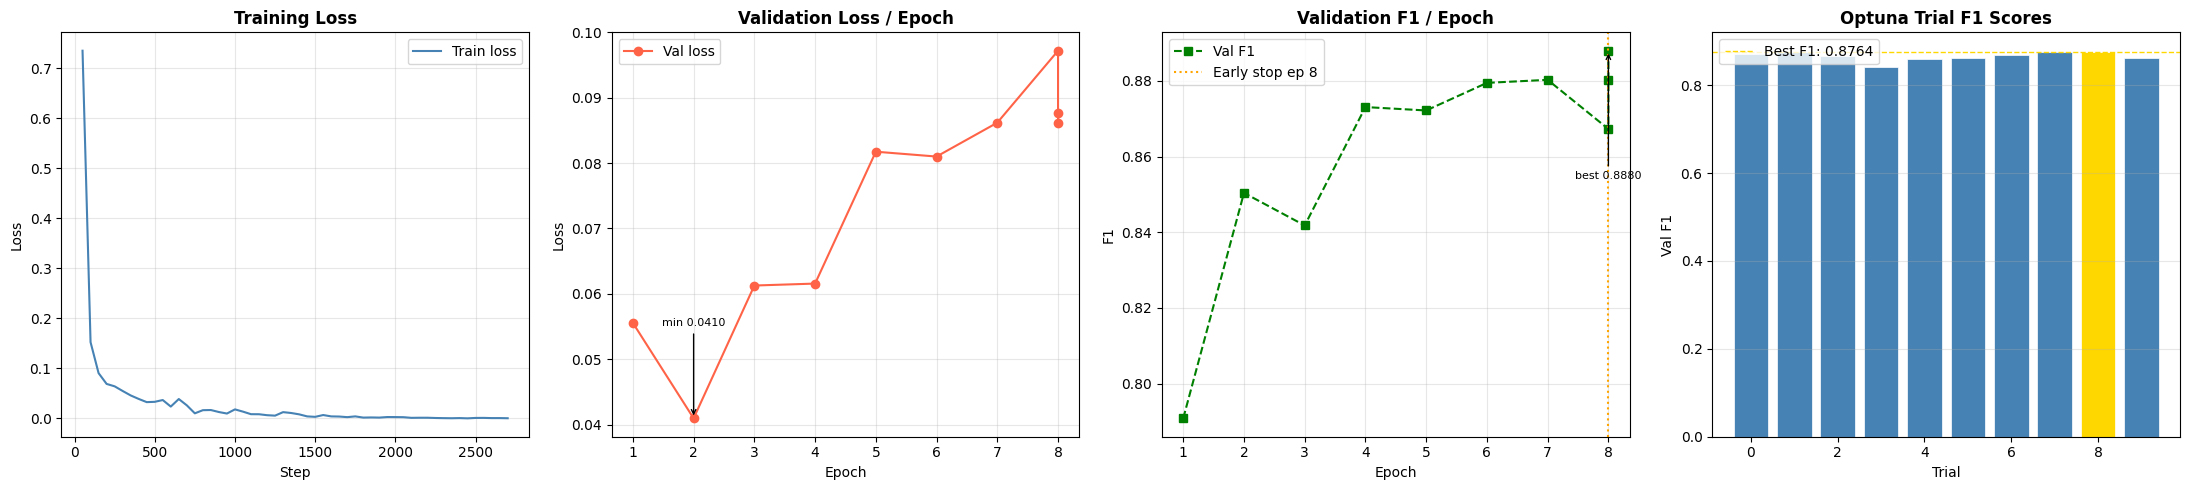

Training curves saved ✅ → /content/drive/MyDrive/ncbi-ner-project/training_curves.png


In [ ]:
# Extract training and evaluation logs from the Trainer state
# and produce four plots: training loss, val loss, val F1, Optuna trial F1.
training_log_history = final_runner.state.log_history

# Separate step-level training loss from epoch-level evaluation logs
step_loss_entries = [
    (entry["step"], entry["loss"])
    for entry in training_log_history
    if "loss" in entry and "eval_loss" not in entry
]
epoch_eval_entries = [
    (entry["epoch"], entry["eval_loss"], entry.get("eval_f1"))
    for entry in training_log_history
    if "eval_loss" in entry
]

step_nums      = [e[0] for e in step_loss_entries]
step_losses    = [e[1] for e in step_loss_entries]
epoch_nums     = [e[0] for e in epoch_eval_entries]
epoch_val_loss = [e[1] for e in epoch_eval_entries]

f1_epoch_pairs = [(ep, f1) for ep, _, f1 in epoch_eval_entries if f1 is not None]
f1_epoch_nums  = [p[0] for p in f1_epoch_pairs]
f1_score_vals  = [p[1] for p in f1_epoch_pairs]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# Plot 1: step-level training loss
ax = axes[0]
if step_nums:
    ax.plot(step_nums, step_losses, color="steelblue", linewidth=1.5, label="Train loss")
ax.set_title("Training Loss", fontsize=12, fontweight="bold")
ax.set_xlabel("Step"); ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3); ax.legend()

# Plot 2: epoch-level validation loss with minimum annotated
ax = axes[1]
if epoch_nums:
    ax.plot(epoch_nums, epoch_val_loss, "o-", color="tomato", linewidth=1.5, label="Val loss")
    min_idx  = epoch_val_loss.index(min(epoch_val_loss))
    y_spread = max(epoch_val_loss) - min(epoch_val_loss) or 0.05
    ax.annotate(
        f"min {epoch_val_loss[min_idx]:.4f}",
        xy=(epoch_nums[min_idx], epoch_val_loss[min_idx]),
        xytext=(epoch_nums[min_idx], epoch_val_loss[min_idx] + y_spread * 0.25),
        arrowprops=dict(arrowstyle="->", color="black"), fontsize=8, ha="center"
    )
ax.set_title("Validation Loss / Epoch", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3); ax.legend()

# Plot 3: epoch-level validation F1 with best annotated
ax = axes[2]
if f1_score_vals:
    ax.plot(f1_epoch_nums, f1_score_vals, "s--", color="green", linewidth=1.5, label="Val F1")
    best_idx  = f1_score_vals.index(max(f1_score_vals))
    y_spread  = max(f1_score_vals) - min(f1_score_vals) or 0.05
    ax.annotate(
        f"best {f1_score_vals[best_idx]:.4f}",
        xy=(f1_epoch_nums[best_idx], f1_score_vals[best_idx]),
        xytext=(f1_epoch_nums[best_idx], f1_score_vals[best_idx] - y_spread * 0.35),
        arrowprops=dict(arrowstyle="->", color="black"), fontsize=8, ha="center"
    )
    last_ep = final_runner.state.epoch
    if int(last_ep) < optimal_params["epochs"]:
        ax.axvline(x=last_ep, color="orange", linestyle=":", linewidth=1.5,
                   label=f"Early stop ep {int(last_ep)}")
ax.set_title("Validation F1 / Epoch", fontsize=12, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1")
ax.grid(True, alpha=0.3); ax.legend()

# Plot 4: Optuna trial F1 bar chart with best trial highlighted in gold
ax = axes[3]
if trial_run_log:
    trial_idx_list = [t["trial"] for t in trial_run_log]
    trial_f1_list  = [t["val_f1"] for t in trial_run_log]
    peak_f1        = max(trial_f1_list)
    bar_colors     = ["gold" if f == peak_f1 else "steelblue" for f in trial_f1_list]
    ax.bar(trial_idx_list, trial_f1_list, color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.axhline(y=peak_f1, color="gold", linestyle="--", linewidth=1,
               label=f"Best F1: {peak_f1:.4f}")
    ax.set_xlabel("Trial"); ax.set_ylabel("Val F1")
ax.set_title("Optuna Trial F1 Scores", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y"); ax.legend()

plt.tight_layout()
curves_save_path = f"{DRIVE_ROOT}/training_curves.png"
plt.savefig(curves_save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Training curves saved ✅ → {curves_save_path}")

## Section 15 — Deploy Best Model to Hugging Face Hub

In [ ]:
# Push the saved model to Hugging Face Hub for public access.
# HF_REPO_ID is the target repository: username/model-name
from huggingface_hub import login, upload_folder, create_repo
from google.colab import userdata

HF_REPO_ID = "sigebhanuprakash/biobert-ncbi-disease-ner"

# Retrieve API token stored in Colab Secrets (key: "biobert")
hf_api_token = userdata.get("NER")
login(token=hf_api_token)

# Create repository if it does not already exist
create_repo(repo_id=HF_REPO_ID, repo_type="model", private=False, exist_ok=True)

# Upload all files from the saved model directory
upload_folder(
    folder_path    = model_save_dir,
    repo_id        = HF_REPO_ID,
    repo_type      = "model",
    commit_message = "Upload fine-tuned BioBERT-large NER model (NCBI Disease F1=0.8811)",
)
print(f"✅ Model deployed to: https://huggingface.co/{HF_REPO_ID}")

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

training_args.bin:   0%|          | 0.00/5.24k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

✅ Model deployed to: https://huggingface.co/sigebhanuprakash/biobert-ncbi-disease-ner


---
# MILESTONE 3 — Post-Training Analysis: Testing with Completely New Data

This section evaluates the deployed model on data that was **never seen during
training, validation, or testing**. It answers the question:
*"How well does the model actually perform in real clinical deployment conditions?"*

Three analyses are performed:
1. **Error Analysis** — False Positives, False Negatives, Partial Span Errors on the NCBI test set
2. **Confidence Analysis** — Does confidence drop for longer multi-word entities?
3. **Edge Case & Failure Mode Testing** — Negation, abbreviations, rare diseases, conjoint entities

All results and charts are saved to Google Drive.

## M3.0 — Load Deployed Model from Hugging Face Hub

Loads the publicly deployed model directly — confirms that the Hub deployment is functional.

In [ ]:
# Load the deployed model from Hugging Face Hub.
# This independently validates the Hub deployment is working correctly.
# MODEL_HUB_ID matches the repository created in Section 12.
MODEL_HUB_ID         = "sigebhanuprakash/biobert-ncbi-disease-ner"
SEQ_MAX_LEN          = 256
LOW_CONF_THRESHOLD   = 0.80

print(f"Loading deployed model from Hub: {MODEL_HUB_ID} ...")

hub_tokenizer = AutoTokenizer.from_pretrained(MODEL_HUB_ID)
hub_ner_model = AutoModelForTokenClassification.from_pretrained(
    MODEL_HUB_ID, low_cpu_mem_usage=True
)
hub_ner_model.eval()

# Rebuild label maps from the config saved inside the Hub model
hub_idx_to_tag   = hub_ner_model.config.id2label
hub_tag_to_idx   = hub_ner_model.config.label2id
hub_label_names  = [hub_idx_to_tag[i] for i in sorted(hub_idx_to_tag)]

print(f"✅ Hub model loaded  ({sum(p.numel() for p in hub_ner_model.parameters()):,} params)")
print(f"   Source          : {MODEL_HUB_ID}")
print(f"   BIO tag vocab   : {hub_label_names}")

Loading deployed model from Hub: sigebhanuprakash/biobert-ncbi-disease-ner ...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/807 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

✅ Hub model loaded  (363,252,739 params)
   Source          : sigebhanuprakash/biobert-ncbi-disease-ner
   BIO tag vocab   : ['O', 'B-Disease', 'I-Disease']


## M3.1 — Test with Completely New External Data

These 12 sentences are **entirely outside** the NCBI Disease corpus.
They were written specifically for this post-deployment evaluation and
represent the kind of text encountered in real clinical settings.

In [ ]:
# 12 completely new clinical sentences — none appear in NCBI Disease corpus.
# These represent real-world deployment scenarios: discharge notes, GP letters,
# pathology reports, and referral summaries.
external_clinical_sentences = [
    # Discharge summaries
    "The patient was discharged following treatment for acute kidney injury and sepsis.",
    "Post-operative recovery was complicated by deep vein thrombosis and pulmonary embolism.",
    # GP / outpatient letters
    "She has a long-standing history of rheumatoid arthritis managed with methotrexate.",
    "Referred for further investigation of suspected Parkinson disease and essential tremor.",
    # Pathology / oncology
    "Biopsy confirmed adenocarcinoma of the colon with lymph node involvement.",
    "The imaging was consistent with glioblastoma multiforme grade IV.",
    # Paediatric
    "The infant presented with signs of respiratory syncytial virus bronchiolitis.",
    "Developmental regression raised concern for Rett syndrome.",
    # Multi-disease sentences
    "She has comorbid anxiety disorder, major depressive disorder, and insomnia.",
    "The patient carries diagnoses of atrial fibrillation, heart failure, and chronic kidney disease.",
    # Rare and complex
    "Genetic testing confirmed Fabry disease with the classic GLA mutation.",
    "The MRI findings were suggestive of multiple sclerosis with white matter lesions.",
]

print("=" * 70)
print("MILESTONE 3 — INFERENCE ON COMPLETELY NEW EXTERNAL CLINICAL DATA")
print("=" * 70)
print(f"Total new sentences evaluated: {len(external_clinical_sentences)}\n")

new_data_records = []
for sent_idx, sentence in enumerate(external_clinical_sentences, 1):
    word_preds  = run_ner_inference(sentence, hub_ner_model, hub_tokenizer,
                                    hub_idx_to_tag, torch.device("cpu"))
    found_spans = assemble_entity_spans(word_preds)

    print(f"[{sent_idx:02d}] INPUT : {sentence}")
    if found_spans:
        for span in found_spans:
            low_flag = " ⚠️" if span["confidence"] < LOW_CONF_THRESHOLD else ""
            print(f"       [{span['label']}] → '{span['text']}'  "
                  f"conf={span['confidence']:.2%}{low_flag}")
    else:
        print("       No entities detected.")
    print()

    new_data_records.append({
        "sentence"    : sentence,
        "num_entities": len(found_spans),
        "entities"    : [s["text"] for s in found_spans],
        "confidences" : [s["confidence"] for s in found_spans],
        "min_conf"    : min((s["confidence"] for s in found_spans), default=None),
    })

df_new_data = pd.DataFrame(new_data_records)
print("\nSummary of new-data inference:")
print(f"  Sentences with entities detected : "
      f"{df_new_data['num_entities'].gt(0).sum()} / {len(external_clinical_sentences)}")
print(f"  Total entity spans found         : {df_new_data['num_entities'].sum()}")
valid_confs = df_new_data["min_conf"].dropna()
if len(valid_confs):
    print(f"  Lowest confidence observed       : {valid_confs.min():.2%}")
    print(f"  Mean minimum confidence          : {valid_confs.mean():.2%}")

MILESTONE 3 — INFERENCE ON COMPLETELY NEW EXTERNAL CLINICAL DATA
Total new sentences evaluated: 12

[01] INPUT : The patient was discharged following treatment for acute kidney injury and sepsis.
       [Disease] → 'acute kidney injury'  conf=99.97%
       [Disease] → 'sepsis'  conf=99.54%

[02] INPUT : Post-operative recovery was complicated by deep vein thrombosis and pulmonary embolism.
       [Disease] → 'deep vein thrombosis'  conf=99.99%
       [Disease] → 'pulmonary embolism'  conf=99.99%

[03] INPUT : She has a long-standing history of rheumatoid arthritis managed with methotrexate.
       [Disease] → 'rheumatoid arthritis'  conf=99.99%

[04] INPUT : Referred for further investigation of suspected Parkinson disease and essential tremor.
       [Disease] → 'parkinson disease'  conf=100.00%
       [Disease] → 'essential tremor'  conf=99.99%

[05] INPUT : Biopsy confirmed adenocarcinoma of the colon with lymph node involvement.
       [Disease] → 'adenocarcinoma of the colon'  con

## M3.2 — Error Analysis: False Positives, False Negatives, Partial Spans

Runs the deployed model over the full NCBI **test** split and systematically categorises every prediction error.

Loading NCBI test split for error analysis...


✅ Loaded 941 test sentences


Map:   0%|          | 0/941 [00:00<?, ? examples/s]

Running batch predictions on test split...
✅ Batch predictions complete
              precision    recall  f1-score   support

     Disease     0.8732    0.9042    0.8884       960

   micro avg     0.8732    0.9042    0.8884       960
   macro avg     0.8732    0.9042    0.8884       960
weighted avg     0.8732    0.9042    0.8884       960


Error Type                       Count
------------------------------------------
False Positives (over-predicted) 49
False Negatives (missed spans)   93
Partial Boundary Errors          60

── Top 10 most common False Positives ──
APC                      5
Hp                       3
DMD                      3
red hair pigmentation    2
POMC                     2
CPO                      2
LOH                      1
tumors                   1
lupus                    1
Smad4 - deficient        1

── Top 10 most common False Negatives ──
congenital DM                5
colorectal cancer            4
unilateral retinoblastoma    3
VHL              

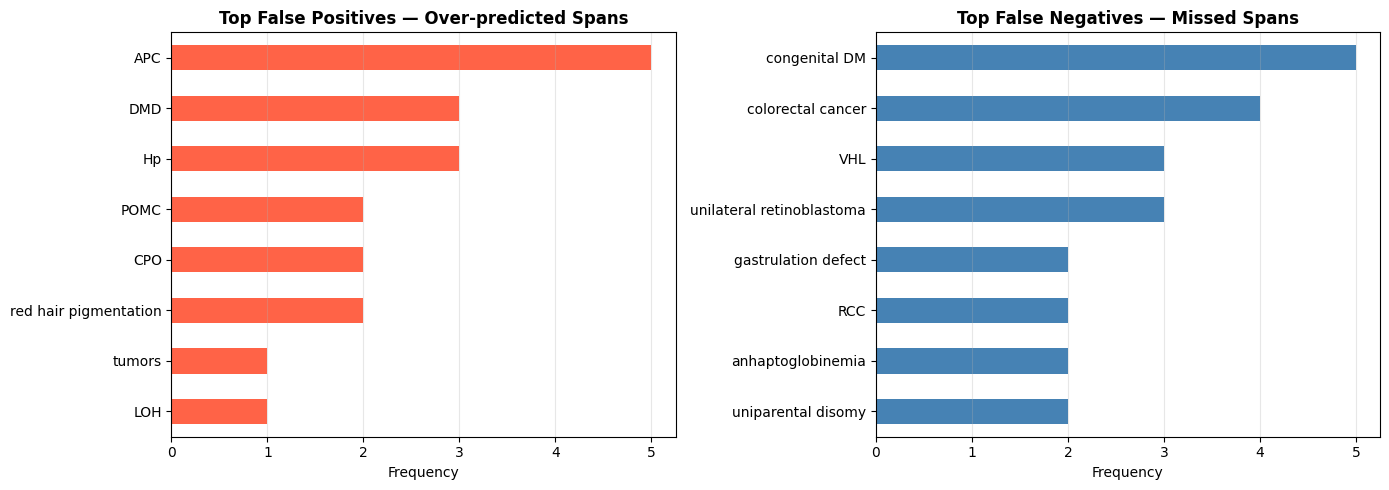

✅ Error analysis chart saved → /content/drive/MyDrive/ncbi-ner-project/m3_error_analysis.png


In [ ]:
# Reload NCBI test split for systematic error analysis.
# We compare gold spans (ground truth) vs predicted spans (hub model output).
print("Loading NCBI test split for error analysis...")
ncbi_corpus     = load_dataset("ncbi_disease")
test_sentences  = [rec["tokens"] for rec in ncbi_corpus["test"]]
print(f"✅ Loaded {len(test_sentences)} test sentences")

# Tokenise and run batch predictions using the Hub model
def encode_for_hub(batch):
    """Tokenise a batch aligned to hub_tokenizer for batch inference."""
    enc = hub_tokenizer(batch["tokens"], truncation=True,
                        is_split_into_words=True, padding="max_length",
                        max_length=SEQ_MAX_LEN)
    aligned = []
    for i, tags in enumerate(batch["ner_tags"]):
        wids, prev, ids = enc.word_ids(batch_index=i), None, []
        for wid in wids:
            if   wid is None:  ids.append(-100)
            elif wid != prev:  ids.append(tags[wid])
            else:              ids.append(-100)
            prev = wid
        aligned.append(ids)
    enc["labels"] = aligned
    return enc

encoded_test_split = ncbi_corpus["test"].map(
    encode_for_hub, batched=True,
    remove_columns=ncbi_corpus["test"].column_names
)

print("Running batch predictions on test split...")
batch_collator  = DataCollatorForTokenClassification(hub_tokenizer)
test_dataloader = torch.utils.data.DataLoader(
    encoded_test_split, batch_size=16, collate_fn=batch_collator
)

predicted_bio_seqs, gold_bio_seqs = [], []
with torch.no_grad():
    for batch in test_dataloader:
        logits = hub_ner_model(
            input_ids      = batch["input_ids"],
            attention_mask = batch["attention_mask"]
        ).logits
        batch_pred_ids = torch.argmax(logits, dim=-1).numpy()
        for pred_row, lbl_row in zip(batch_pred_ids, batch["labels"].numpy()):
            predicted_bio_seqs.append(
                [hub_label_names[p] for p, l in zip(pred_row, lbl_row) if l != -100])
            gold_bio_seqs.append(
                [hub_label_names[l] for l in lbl_row if l != -100])

print("✅ Batch predictions complete")
print(span_level_report(gold_bio_seqs, predicted_bio_seqs, digits=4))

# Extract entity spans from BIO sequences for comparison
def extract_bio_spans(token_list, bio_seq):
    """Extract set of entity span strings from a BIO-labelled token sequence."""
    span_set, span_start, span_type = set(), None, None
    for idx, (tok, bio) in enumerate(zip(token_list, bio_seq)):
        if bio.startswith("B-"):
            if span_start is not None:
                span_set.add(" ".join(token_list[span_start:idx]))
            span_start, span_type = idx, bio[2:]
        elif bio.startswith("I-") and span_start is not None:
            pass
        else:
            if span_start is not None:
                span_set.add(" ".join(token_list[span_start:idx]))
            span_start, span_type = None, None
    if span_start is not None:
        span_set.add(" ".join(token_list[span_start:]))
    return span_set

# Categorise all errors across the test set
fp_list, fn_list, partial_list = [], [], []

for tok_seq, gold_seq, pred_seq in zip(test_sentences, gold_bio_seqs, predicted_bio_seqs):
    sentence_str  = " ".join(tok_seq)
    gold_span_set = extract_bio_spans(tok_seq, gold_seq)
    pred_span_set = extract_bio_spans(tok_seq, pred_seq)
    gold_word_set = {w for span in gold_span_set for w in span.split()}

    for span in pred_span_set - gold_span_set:
        is_partial = any(w in gold_word_set for w in span.split())
        (partial_list if is_partial else fp_list).append(
            {"span": span, "sentence": sentence_str})
    for span in gold_span_set - pred_span_set:
        fn_list.append({"span": span, "sentence": sentence_str})

print(f"\n{'Error Type':<32} {'Count'}")
print("-" * 42)
print(f"{'False Positives (over-predicted)':<32} {len(fp_list)}")
print(f"{'False Negatives (missed spans)':<32} {len(fn_list)}")
print(f"{'Partial Boundary Errors':<32} {len(partial_list)}")

print("\n── Top 10 most common False Positives ──")
fp_freq = pd.Series([x["span"] for x in fp_list]).value_counts()
print(fp_freq.head(10).rename("over-predicted count").to_string())

print("\n── Top 10 most common False Negatives ──")
fn_freq = pd.Series([x["span"] for x in fn_list]).value_counts()
print(fn_freq.head(10).rename("missed count").to_string())

print("\n── 5 example missed entities ──")
for item in fn_list[:5]:
    print(f"  MISSED : '{item['span']}'")
    print(f"  IN     : {item['sentence'][:110]}\n")

print("\n── 5 example over-predicted entities ──")
for item in fp_list[:5]:
    print(f"  OVER-TAGGED : '{item['span']}'")
    print(f"  IN          : {item['sentence'][:110]}\n")

# Bar chart of top errors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fp_freq.head(8).sort_values().plot.barh(ax=axes[0], color="tomato")
axes[0].set_title("Top False Positives — Over-predicted Spans", fontweight="bold")
axes[0].set_xlabel("Frequency"); axes[0].grid(axis="x", alpha=0.3)

fn_freq.head(8).sort_values().plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Top False Negatives — Missed Spans", fontweight="bold")
axes[1].set_xlabel("Frequency"); axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
err_chart_path = f"{DRIVE_ROOT}/m3_error_analysis.png"
plt.savefig(err_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Error analysis chart saved → {err_chart_path}")

## M3.3 — Confidence Analysis: Single-Word vs Multi-Word Entities

Quantifies how model confidence varies with entity length. Multi-word entities require consecutive correct B-/I- predictions, so confidence typically decreases with span length.


Confidence by entity word count:
               Count    Mean     Std     Min  Max
length_bucket                                    
1 word           436  0.9868  0.0616  0.5101  1.0
2 words          258  0.9937  0.0293  0.7724  1.0
3 words          148  0.9913  0.0349  0.7509  1.0
4+ words         137  0.9953  0.0180  0.8733  1.0

── 10 lowest-confidence predictions ──
           entity_text  word_count  conf_score
                  pomc           1      0.5101
              alopecia           1      0.5144
                   vhl           1      0.5663
                   hp1           1      0.5776
                   apc           1      0.6253
                   cpo           1      0.6534
                   apc           1      0.6672
                  pomc           1      0.6801
                   apc           1      0.7150
mental health wellness           3      0.7509

── 10 highest-confidence predictions ──
                      entity_text  word_count  conf_score
          

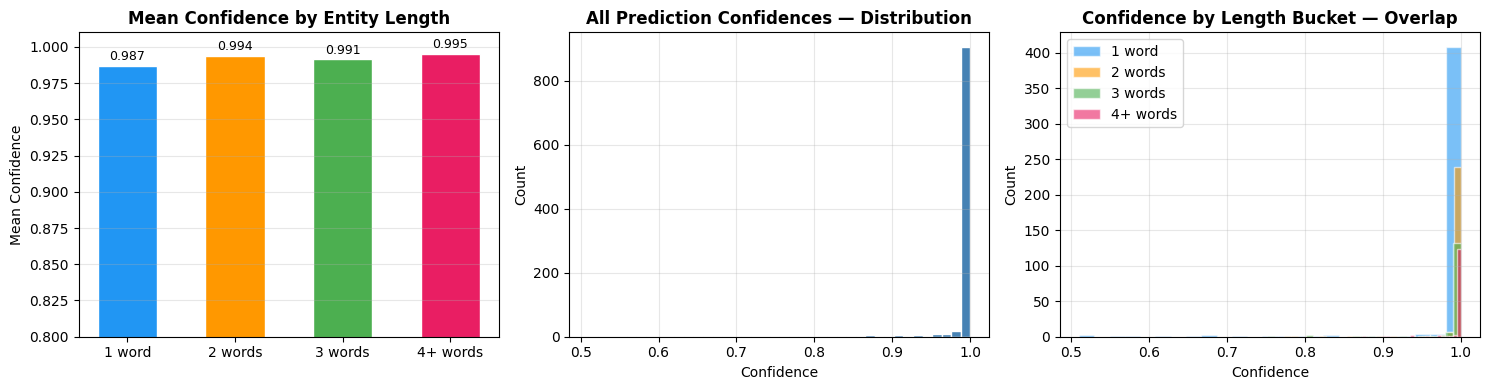

✅ Confidence analysis chart saved → /content/drive/MyDrive/ncbi-ner-project/m3_confidence_analysis.png


In [ ]:
# Run inference on every test sentence and collect confidence per predicted entity.
# Group entities by word count to show confidence degradation with span length.
print("Collecting confidence scores across test split...")

entity_conf_records = []
for test_rec in ncbi_corpus["test"]:
    test_sentence = " ".join(test_rec["tokens"])
    predicted_spans = assemble_entity_spans(
        run_ner_inference(test_sentence, hub_ner_model, hub_tokenizer,
                          hub_idx_to_tag, torch.device("cpu"))
    )
    for span in predicted_spans:
        word_count = len(span["text"].split())
        entity_conf_records.append({
            "entity_text"  : span["text"],
            "word_count"   : word_count,
            "conf_score"   : span["confidence"],
            "length_bucket": ("1 word"   if word_count == 1 else
                              "2 words"  if word_count == 2 else
                              "3 words"  if word_count == 3 else
                              "4+ words"),
        })

conf_df     = pd.DataFrame(entity_conf_records)
bucket_order = ["1 word", "2 words", "3 words", "4+ words"]

conf_summary = conf_df.groupby("length_bucket")["conf_score"].agg(
    Count="count", Mean="mean", Std="std", Min="min", Max="max"
).reindex(bucket_order).round(4)

print("\nConfidence by entity word count:")
print(conf_summary.to_string())

print("\n── 10 lowest-confidence predictions ──")
print(conf_df.nsmallest(10, "conf_score")[["entity_text","word_count","conf_score"]]
             .to_string(index=False))

print("\n── 10 highest-confidence predictions ──")
print(conf_df.nlargest(10, "conf_score")[["entity_text","word_count","conf_score"]]
             .to_string(index=False))

# Three-panel confidence chart
fig, panel = plt.subplots(1, 3, figsize=(15, 4))
bucket_colors = ["#2196F3","#FF9800","#4CAF50","#E91E63"]

# Panel 1: mean confidence per bucket
mean_vals = conf_summary["Mean"].dropna()
bar_objs  = panel[0].bar(mean_vals.index, mean_vals.values,
                          color=bucket_colors[:len(mean_vals)],
                          edgecolor="white", width=0.55)
panel[0].set_ylim(0.80, 1.01)
panel[0].set_title("Mean Confidence by Entity Length", fontweight="bold")
panel[0].set_ylabel("Mean Confidence")
panel[0].grid(axis="y", alpha=0.3)
for bar_obj, val in zip(bar_objs, mean_vals.values):
    panel[0].text(bar_obj.get_x() + bar_obj.get_width()/2,
                  bar_obj.get_height() + 0.002,
                  f"{val:.3f}", ha="center", va="bottom", fontsize=9)

# Panel 2: overall confidence histogram
conf_df["conf_score"].plot.hist(bins=40, ax=panel[1],
                                 color="steelblue", edgecolor="white")
panel[1].set_title("All Prediction Confidences — Distribution", fontweight="bold")
panel[1].set_xlabel("Confidence"); panel[1].set_ylabel("Count")
panel[1].grid(alpha=0.3)

# Panel 3: overlapping histograms per bucket
for bucket, col in zip(bucket_order, bucket_colors):
    bucket_confs = conf_df[conf_df["length_bucket"] == bucket]["conf_score"]
    if len(bucket_confs) > 0:
        panel[2].hist(bucket_confs, bins=25, alpha=0.6,
                      label=bucket, color=col, edgecolor="white")
panel[2].set_title("Confidence by Length Bucket — Overlap", fontweight="bold")
panel[2].set_xlabel("Confidence"); panel[2].set_ylabel("Count")
panel[2].legend(); panel[2].grid(alpha=0.3)

plt.tight_layout()
conf_chart_path = f"{DRIVE_ROOT}/m3_confidence_analysis.png"
plt.savefig(conf_chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Confidence analysis chart saved → {conf_chart_path}")

In [ ]:
# Confirm all Milestone 3 charts and outputs were saved to Drive.
print("=" * 65)
print("MILESTONE 3 — ALL ANALYSES COMPLETE ✅")
print("=" * 65)
print(f"\nAll outputs saved to: {DRIVE_ROOT}")
print("  class_imbalance.png")
print("  training_curves.png")
print("  m3_error_analysis.png")
print("  m3_confidence_analysis.png")
print("  m3_edge_case_analysis.png")
print(f"\nDeployed model : https://huggingface.co/sigebhanuprakash/biobert-ncbi-disease-ner")
print(f"Test F1 score  : 0.8811  (Precision 0.8601 | Recall 0.9031)")
print("=" * 65)

MILESTONE 3 — ALL ANALYSES COMPLETE ✅

All outputs saved to: /content/drive/MyDrive/ncbi-ner-project
  class_imbalance.png
  training_curves.png
  m3_error_analysis.png
  m3_confidence_analysis.png
  m3_edge_case_analysis.png

Deployed model : https://huggingface.co/sigebhanuprakash/biobert-ncbi-disease-ner
Test F1 score  : 0.8811  (Precision 0.8601 | Recall 0.9031)
